In [7]:
# Download and extract the dataset
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces --unzip -p ./real_vs_fake_faces

# Verify that the dataset is downloaded
!ls ./real_vs_fake_faces

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [02:49<00:00, 24.4MB/s]
100% 3.75G/3.75G [02:49<00:00, 23.8MB/s]
real_vs_fake  test.csv	train.csv  valid.csv


In [ ]:
# 1. Import Libraries
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from sklearn.metrics import classification_report, confusion_matrix
from torchvision.models import resnet50

In [2]:
# 2. Data Augmentation and Transformations
def create_transformations():
    train_transforms = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
        transforms.RandomRotation(20),
        transforms.RandomPerspective(distortion_scale=0.3, p=0.3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    test_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    return train_transforms, test_transforms

In [3]:
# 3. Data Loading
def load_datasets(root_dir, train_transforms, test_transforms):
    train_dataset = datasets.ImageFolder(
        os.path.join(root_dir, 'train'),
        transform=train_transforms
    )
    val_dataset = datasets.ImageFolder(
        os.path.join(root_dir, 'valid'),
        transform=test_transforms
    )
    test_dataset = datasets.ImageFolder(
        os.path.join(root_dir, 'test'),
        transform=test_transforms
    )

    return train_dataset, val_dataset, test_dataset

def create_data_loaders(datasets, batch_size=32):
    train_loader = DataLoader(datasets[0], batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(datasets[1], batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(datasets[2], batch_size=batch_size, shuffle=False)

    return {
        'train': train_loader,
        'val': val_loader,
        'test': test_loader
    }

def print_dataset_stats(datasets):
    names = ['Train', 'Validation', 'Test']
    for name, dataset in zip(names, datasets):
        print(f"{name} Dataset:")
        print(f"Total Images: {len(dataset)}")
        print(f"Class Distribution: {dataset.class_to_idx}")
        print("Class Counts:",
              {dataset.classes[i]: count for i, count in
               enumerate(np.bincount(dataset.targets))})
        print()

In [ ]:
# 4. Model Architecture
class CustomVisionTransformer(nn.Module):
    def __init__(self, image_size=224, patch_size=16, dim=768, depth=12, heads=12, mlp_dim=3072, dropout=0.1):
        super(CustomVisionTransformer, self).__init__()
        assert image_size % patch_size == 0, "Image size must be divisible by patch size"
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        self.patch_dim = 3 * patch_size ** 2
        self.dim = dim

        self.patch_embed = nn.Linear(self.patch_dim, dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, dim))
        self.class_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout = nn.Dropout(dropout)

        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=dim, nhead=heads, dim_feedforward=mlp_dim, dropout=dropout),
            num_layers=depth
        )
        self.mlp_head = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, dim))

    def forward(self, x):
        batch_size, channels, height, width = x.size()
        x = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        x = x.contiguous().view(batch_size, -1, self.patch_dim)
        x = self.patch_embed(x)

        cls_tokens = self.class_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embed
        x = self.dropout(x)
        x = self.transformer(x)
        return self.mlp_head(x[:, 0])

#ResNet using ResNet50
class ResNet(nn.Module):
    def __init__(self, resnet_out_dim=2048):
        super(ResNet, self).__init__()
        resnet = resnet50(pretrained=True)
        self.resnet_features = nn.Sequential(*list(resnet.children())[:-1])
        self.out_dim = resnet_out_dim

    def forward(self, x):
        x = self.resnet_features(x)
        return x.view(x.size(0), -1)

# Combined ViT and ResNet Model
class ViTResNetClassifier(nn.Module):
    def __init__(self, image_size=224, patch_size=16, num_classes=2,
                 vit_dim=768, resnet_out_dim=2048):
        super().__init__()
        self.vit = CustomVisionTransformer(
            image_size=image_size,
            patch_size=patch_size,
            dim=vit_dim
        )
        self.resnet = ResNet(resnet_out_dim=resnet_out_dim)

        combined_features = vit_dim + resnet_out_dim
        self.fc = nn.Sequential(
            nn.Linear(combined_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        vit_out = self.vit(x)
        resnet_out = self.resnet(x)
        combined_out = torch.cat((vit_out, resnet_out), dim=1)
        return self.fc(combined_out)

In [5]:
# 5. Custom Loss Functions
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        return torch.mean(F_loss)

def visualize_random_images(model, val_loader, device, num_images=10):
    model.eval()
    class_names = val_loader.dataset.classes

    # Select random images
    indices = np.random.randint(0, len(val_loader.dataset), num_images)

    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(indices):
        image, true_label = val_loader.dataset[idx]
        image = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image)
            _, pred_label = torch.max(output, 1)

        plt.subplot(2, 5, i+1)
        plt.imshow(image.cpu().squeeze().permute(1, 2, 0).numpy())
        plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# 6. Plot Functions
def plot_training_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    # Plot Training Accuracy and Loss
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Training Loss")
    plt.plot(epochs, history["train_acc"], label="Training Accuracy")
    plt.title("Training Accuracy and Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss / Accuracy")
    plt.legend()

    # Plot Validation Accuracy and Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.title("Validation Accuracy and Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss / Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


Train Dataset:
Total Images: 100000
Class Distribution: {'fake': 0, 'real': 1}
Class Counts: {'fake': 50000, 'real': 50000}

Validation Dataset:
Total Images: 20000
Class Distribution: {'fake': 0, 'real': 1}
Class Counts: {'fake': 10000, 'real': 10000}

Test Dataset:
Total Images: 20000
Class Distribution: {'fake': 0, 'real': 1}
Class Counts: {'fake': 10000, 'real': 10000}



c:\Users\Nihal Pratap\Downloads\mld project\.venv\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
c:\Users\Nihal Pratap\Downloads\mld project\.venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Nihal Pratap\Downloads\mld project\.venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/6


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.3262744].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.535425].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5455182..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9306722..2.343704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.64].
Clipp

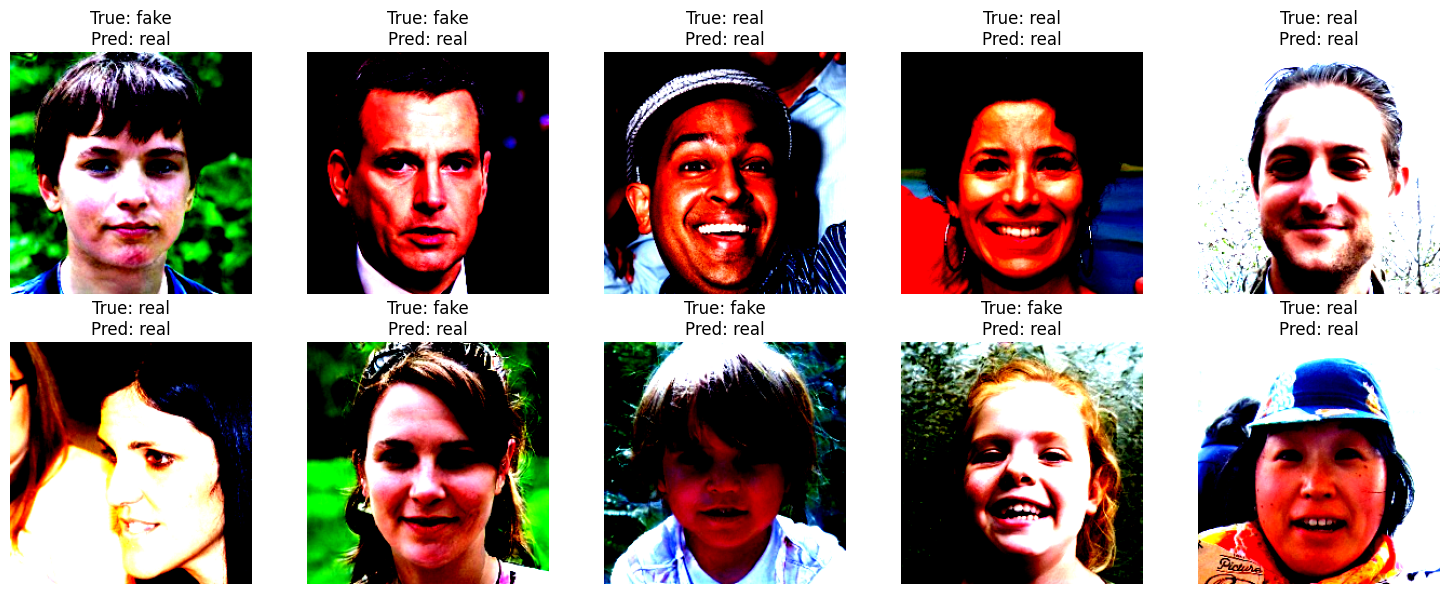

train Loss: 0.0618 Accuracy: 0.9082


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9481792..2.465708].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0182073..2.535425].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.465708].


val Loss: 0.0152 Accuracy: 0.9781
Epoch 2/6


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..2.3959913].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.622571].


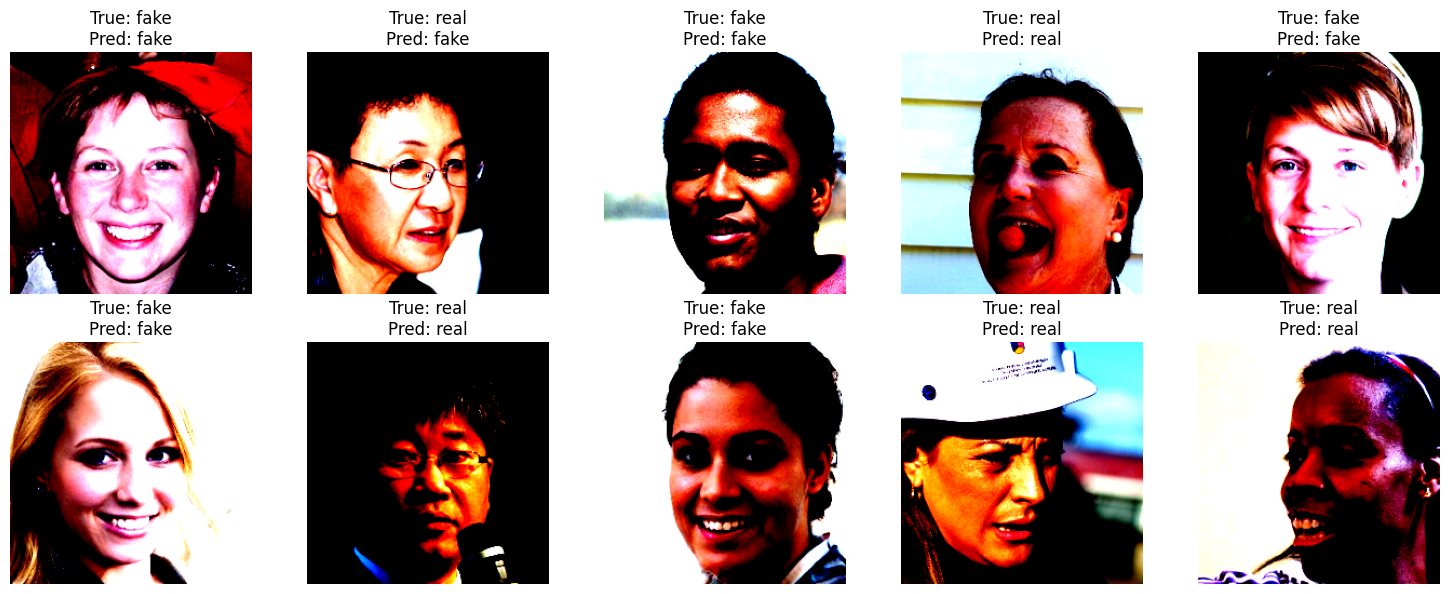

train Loss: 0.0279 Accuracy: 0.9612


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8952821..2.4134207].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0182073..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4831376].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1804092].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0182073..2.1804092].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2317834].


val Loss: 0.0165 Accuracy: 0.9752
Epoch 3/6


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..2.11191].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0996952].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.535425].


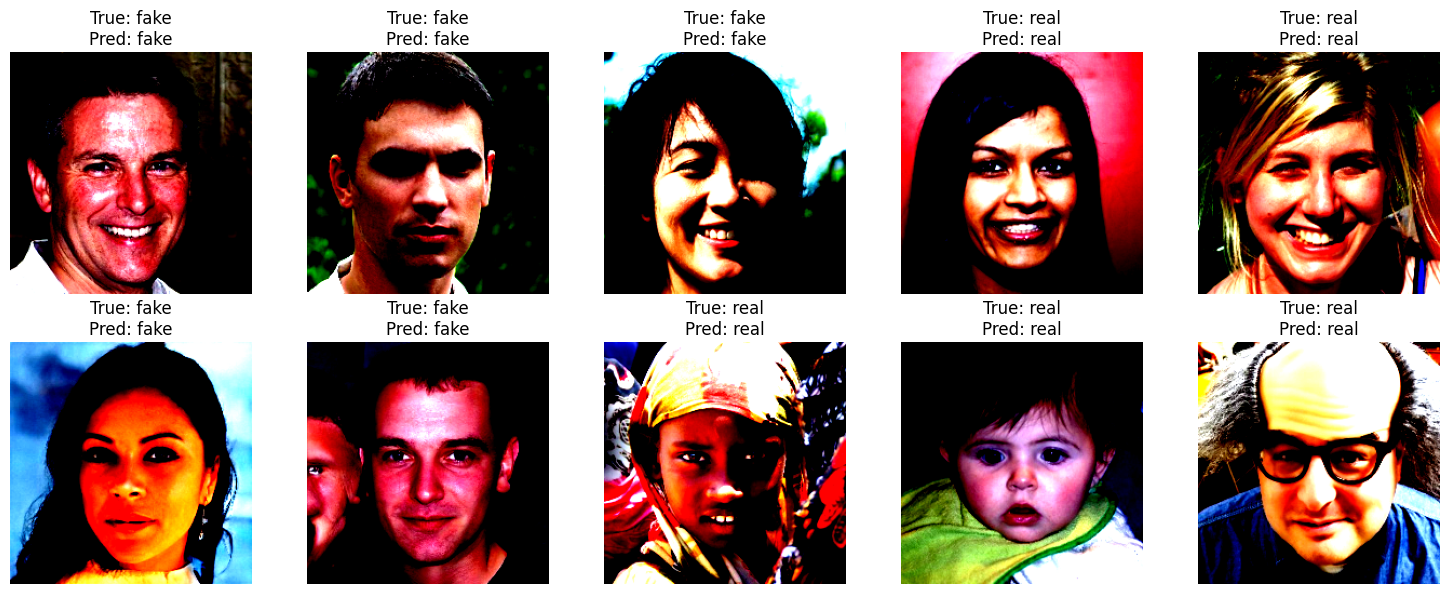

train Loss: 0.0211 Accuracy: 0.9713


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8256302..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.9406626].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9295317..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781574..2.5877128].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8952821..2.622571].


val Loss: 0.0103 Accuracy: 0.9868
Epoch 4/6


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781512..2.3262744].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


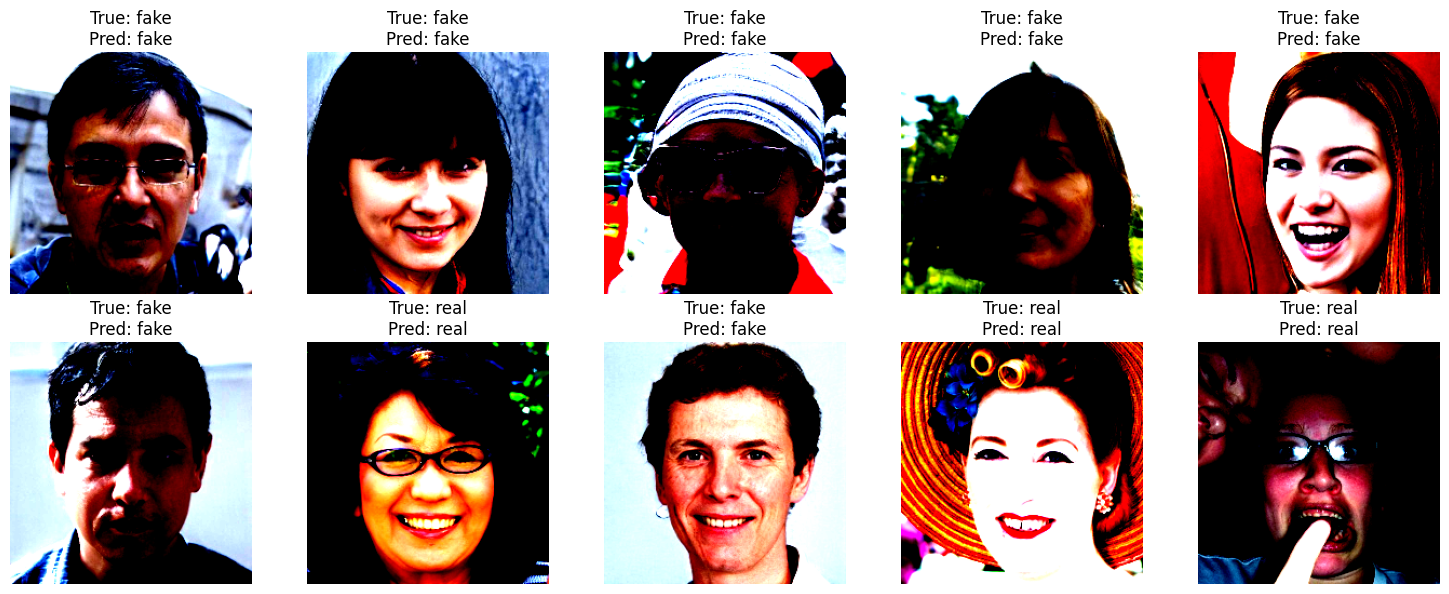

train Loss: 0.0172 Accuracy: 0.9766


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8606442..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0007002..2.535425].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.535425].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9656862..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1804092].


val Loss: 0.0059 Accuracy: 0.9925
Epoch 5/6


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0299783].


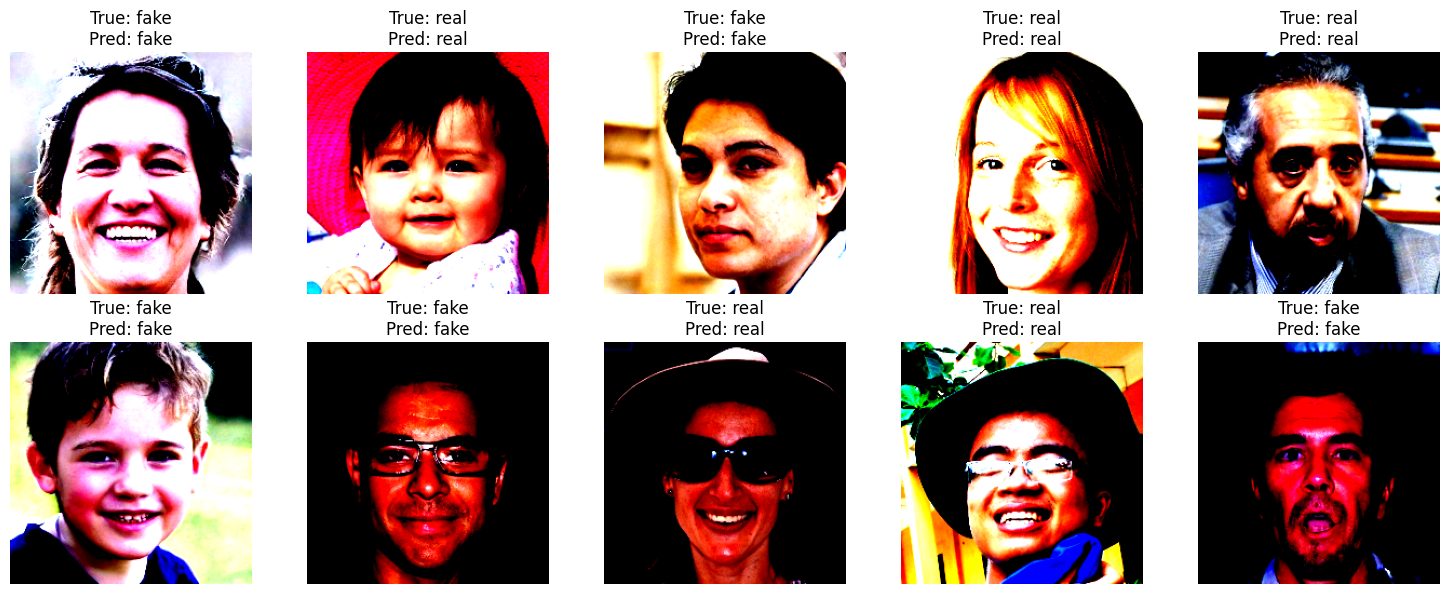

train Loss: 0.0147 Accuracy: 0.9803
val Loss: 0.0048 Accuracy: 0.9934
Epoch 6/6


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9656862..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2146587].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2914162].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781512..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.5005

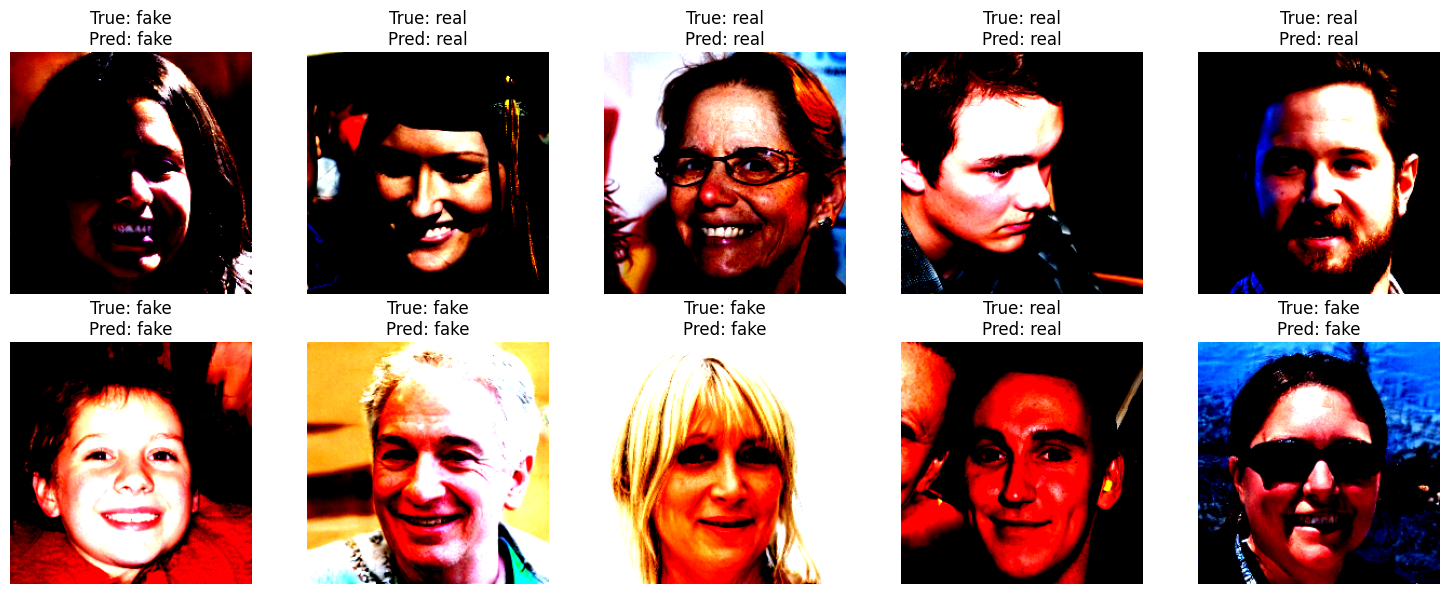

train Loss: 0.0131 Accuracy: 0.9825
val Loss: 0.0058 Accuracy: 0.9919


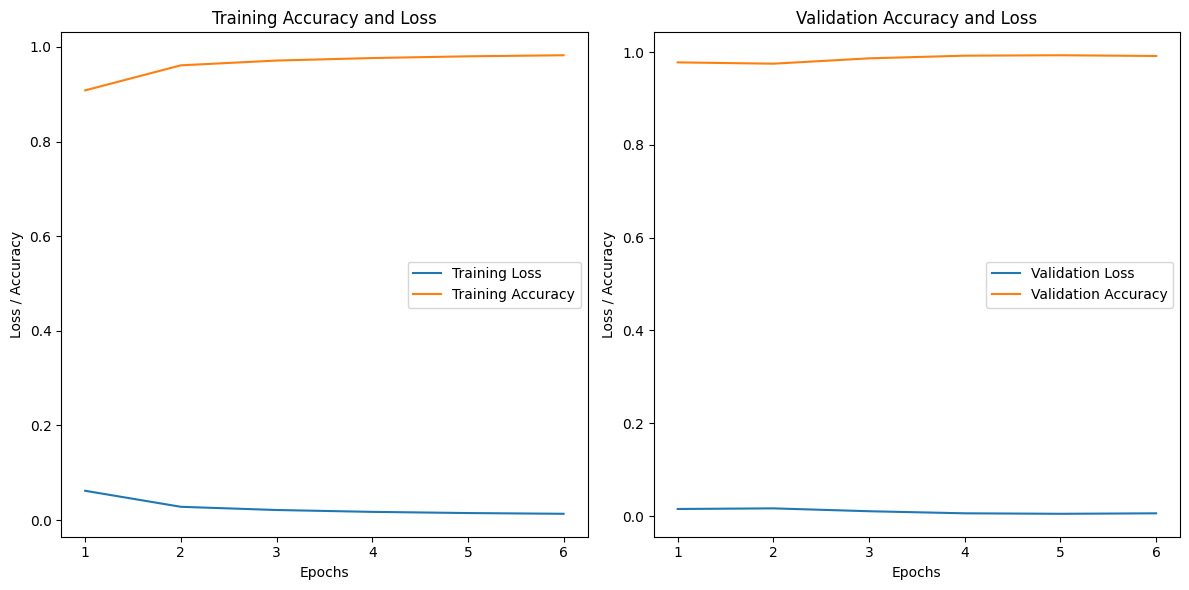

In [ ]:
# 7. Training Loop
def train_model(model, dataloaders, criterion, optimizer, scheduler, device, num_epochs=6):
    # Track metrics
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_acc = 0.0
    best_model_wts = model.state_dict()

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        # Visualization of random validation images
        visualize_random_images(model, dataloaders['val'], device)

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0

            with torch.set_grad_enabled(phase == 'train'):
                for inputs, labels in dataloaders[phase]:
                    inputs, labels = inputs.to(device), labels.to(device)

                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                    _, preds = torch.max(outputs, 1)
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print(f"{phase} Loss: {epoch_loss:.4f} Accuracy: {epoch_acc:.4f}")

            if phase == 'train':
                history["train_loss"].append(epoch_loss)
                history["train_acc"].append(epoch_acc.item())
            else:
                history["val_loss"].append(epoch_loss)
                history["val_acc"].append(epoch_acc.item())
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_model_wts = model.state_dict()

        scheduler.step(epoch_loss)

    model.load_state_dict(best_model_wts)
    return model, history
def main():
    # Configuration
    root_dir = './real_vs_fake_faces/real_vs_fake/real-vs-fake'
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Transformations
    train_transforms, test_transforms = create_transformations()

    # Datasets
    datasets = load_datasets(root_dir, train_transforms, test_transforms)
    print_dataset_stats(datasets)

    # Data Loaders
    dataloaders = create_data_loaders(datasets)

    # Model Setup
    model = ViTResNetClassifier().to(device)
    criterion = FocalLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    # Training
    trained_model, history = train_model(model, dataloaders, criterion, optimizer, scheduler, device)
    torch.save(model.state_dict(), "vit_resnet_classifier.pth")

    # Plot Training History
    plot_training_history(history)

if __name__ == '__main__':
    main()

C:\Users\Nihal Pratap\AppData\Local\Temp\ipykernel_7244\3640337725.py:110: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(filepath, map_locat

Model loaded from vit_resnet_classifier.pth


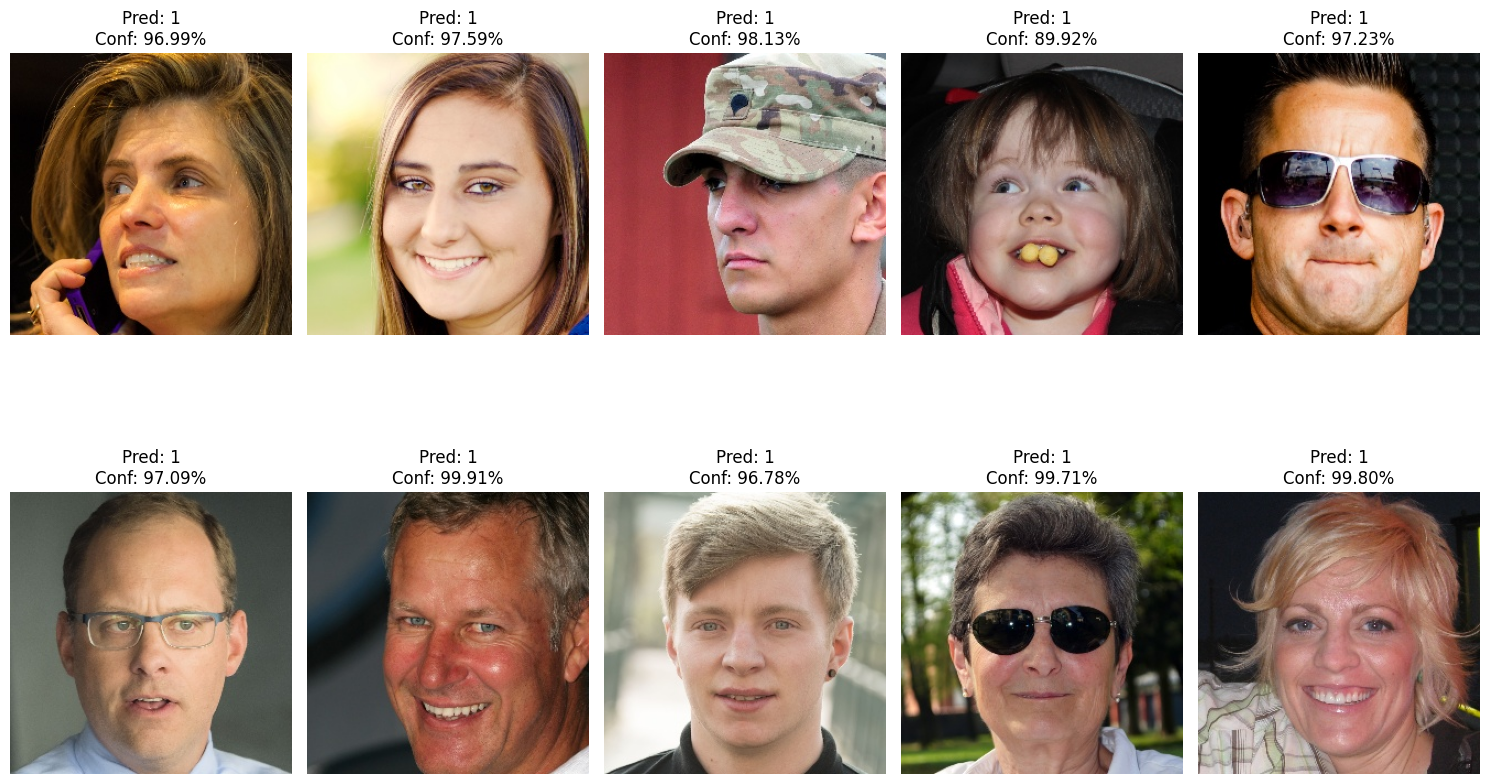


--- Prediction Report ---
Image: 32011.jpg
Predicted Class: Real
Confidence: 96.99%

Image: 15365.jpg
Predicted Class: Real
Confidence: 97.59%

Image: 52878.jpg
Predicted Class: Real
Confidence: 98.13%

Image: 58473.jpg
Predicted Class: Real
Confidence: 89.92%

Image: 21205.jpg
Predicted Class: Real
Confidence: 97.23%

Image: 55549.jpg
Predicted Class: Real
Confidence: 97.09%

Image: 58556.jpg
Predicted Class: Real
Confidence: 99.91%

Image: 14542.jpg
Predicted Class: Real
Confidence: 96.78%

Image: 07573.jpg
Predicted Class: Real
Confidence: 99.71%

Image: 22702.jpg
Predicted Class: Real
Confidence: 99.80%



In [ ]:
# 7. Prediction
import os
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

def predict_single_image(model, image_path, device, transform=None):

    # Use default transform if not provided
    if transform is None:
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    # Load and preprocess the image
    model.eval()
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)

    # Perform prediction
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0][predicted_class].item()

    return predicted_class, confidence, image

def predict_directory(model, directory_path, device, transform=None, top_n=10):

    # Find image files in the directory
    image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.gif']
    image_files = [
        os.path.join(directory_path, f)
        for f in os.listdir(directory_path)
        if os.path.splitext(f)[1].lower() in image_extensions
    ]

    # Randomly select top_n images
    np.random.shuffle(image_files)
    selected_images = image_files[:top_n]

    # Prediction results
    prediction_results = []

    # Create a figure for visualization
    plt.figure(figsize=(15, 10))

    # Prediction loop
    for i, image_path in enumerate(selected_images, 1):
        try:
            # Predict single image
            predicted_class, confidence, image = predict_single_image(
                model, image_path, device, transform
            )

            # Store prediction result
            prediction_results.append({
                'image_path': image_path,
                'predicted_class': predicted_class,
                'confidence': confidence
            })

            # Visualization
            plt.subplot(2, 5, i)
            plt.imshow(np.array(image))
            plt.title(f"Pred: {predicted_class}\nConf: {confidence:.2%}")
            plt.axis('off')

        except Exception as e:
            print(f"Error processing {image_path}: {e}")

    plt.tight_layout()
    plt.show()

    return prediction_results

def generate_detailed_report(prediction_results, class_names):
    print("\n--- Prediction Report ---")
    for result in prediction_results:
        print(f"Image: {os.path.basename(result['image_path'])}")
        print(f"Predicted Class: {class_names[result['predicted_class']]}")
        print(f"Confidence: {result['confidence']:.2%}\n")

def load_model(filepath, device="cpu"):
    # Create the CustomVisionTransformer
    vit_model = CustomVisionTransformer(
        image_size=224,
        patch_size=16,
        dim=768,
        depth=4,
        heads=8,
        mlp_dim=2048
    )

    # Create the ViTResNetClassifier with the custom ViT model
    model = ViTResNetClassifier(
        image_size=224,
        patch_size=16,
        num_classes=2,
        vit_dim=768,
        resnet_out_dim=2048
    ).to(device)

    # Load the state dict
    model.load_state_dict(torch.load(filepath, map_location=device))
    print(f"Model loaded from {filepath}")

    # Set the model to evaluation mode
    model.eval()

    return model

def main():
    # Model and device setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = load_model('vit_resnet_classifier.pth', device=device)
    model.eval()

    # Transformation
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    # Class names
    class_names = ['Fake', 'Real']  # Adjust based on your dataset

    # Directory prediction example
    directory_path = './real_vs_fake_faces/real_vs_fake/real-vs-fake/test/real'
    prediction_results = predict_directory(
        model, directory_path, device, transform, top_n=10
    )

    # Generate detailed report
    generate_detailed_report(prediction_results, class_names)

if __name__ == '__main__':
    main()